## 🎓 **Lesson 3 Activity — Matplotlib Basics: Plotting with `pyplot`**

### 🧠 Objective:

Create and customize a simple line chart using Matplotlib to visualize data trends.

---

### Practical Task 1 — Custom Line Plot**

Use your own **made-up data** to complete these tasks:

1. Create a set of **x-values** and **y-values** (for example: daily sales, temperature, or steps walked).
2. Plot a **basic line graph** using `plt.plot()`.
3. Add:

   * Title
   * Labels for both axes
   * A legend
   * A grid
4. Customize:

   * Line **color**
   * **Style** (solid, dashed, etc.)
   * **Markers** (circle, square, etc.)
5. Save your plot as an image file (e.g., `my_plot.png`).


In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Data:

day_no = np.arange(1,100+1)
daily_sales = np.random.randint(10000, 20000, 100)

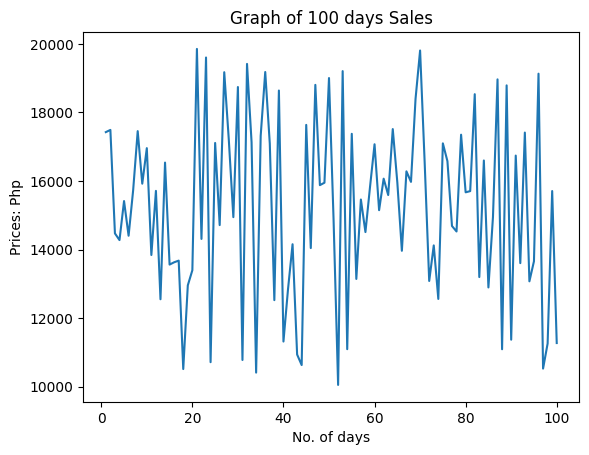

In [3]:
plt.title("Graph of 100 days Sales")
plt.xlabel("No. of days")
plt.ylabel("Prices: Php")

plt.plot(day_no, daily_sales)

#### Lets make a clear graph of average in each region for smoother graph

* Get average of each chunk (10)
* Store it in an array
* Plot the new array

In [4]:
def get_avg_by_chunk(array, chunk):
    new_array = []

    # Loop through data in steps of 'chunk' size
    for i in range(0, len(array), chunk):
        # Take a slice of 10 items (or whatever chunk size)
        avg = np.mean(array[i:i + chunk])
        new_array.append(avg)

    return np.array(new_array)

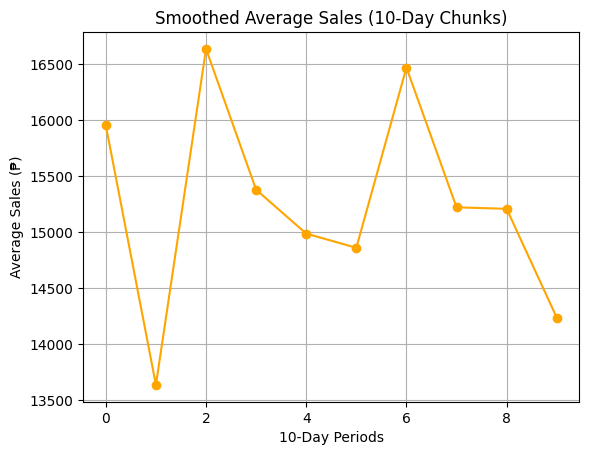

In [5]:
avg_sales = get_avg_by_chunk(daily_sales, 10)
plt.plot(avg_sales, marker='o', color='orange')
plt.title("Smoothed Average Sales (10-Day Chunks)")
plt.xlabel("10-Day Periods")
plt.ylabel("Average Sales (₱)")
plt.grid(True)
plt.show()


### Short NumPy Trick
 * If your array length divides evenly by the chunk size (like 100 ÷ 10 = 10):

In [6]:
avg_sales = daily_sales.reshape(-1, 10).mean(axis=1)


Let’s break it down:

1. `daily_sales.reshape(-1, 10)`
   → Reshapes your 1D array of 100 items into **10 rows × 10 columns**
   (each row = 1 chunk of 10 days)

2. `.mean(axis=1)`
   → Takes the **average across each row**, giving you **10 averages**

3. The result is your **smooth 10-point array** ready to plot!


# This is a Note/Review in using reshape()
## 🧠 **NumPy `.reshape()` and `-1` — Summary Notes**

### 🎯 Purpose:

`reshape()` changes the **shape (rows × columns)** of an array **without changing its data**.

---

### 🧩 **Basic Syntax:**

```python
array.reshape(rows, cols)
```

* You must have:
  **rows × cols = total number of elements** in the array.

Example:

```python
arr = np.arange(1, 13)  # 12 elements
arr.reshape(3, 4)       # ✅ works → 3x4 = 12
arr.reshape(2, 6)       # ✅ works → 2x6 = 12
arr.reshape(5, 2)       # ❌ error → 5x2=10 ≠ 12
```

---

### 🔢 **Using `-1` — Auto Dimension**

`-1` tells NumPy:

> “Figure out this dimension for me automatically.”

Example:

```python
arr.reshape(-1, 4)
```

→ NumPy calculates the needed number of rows.

🧮 If array has 12 elements:

```
12 ÷ 4 = 3  → arr.reshape(3, 4)
```

So:

```python
arr.reshape(-1, 4)  # Same as arr.reshape(3, 4)
```

---

### ⚠️ **Rules for Using `-1`**

1. You can use only **one `-1`** per reshape.
   (You can’t use `reshape(-1, -1)`.)
2. The total number of elements must divide evenly by the other dimension.
   Example:

   * ✅ `np.arange(12).reshape(-1, 3)` → works (12 ÷ 3 = 4)
   * ❌ `np.arange(10).reshape(-1, 3)` → error (10 ÷ 3 not whole)
3. Use `-1` when you **don’t know or don’t care** how many rows there will be — you just want columns (or vice versa).

---

### 💡 **Practical Uses**

| Use Case                     | Example               | Meaning                             |
| ---------------------------- | --------------------- | ----------------------------------- |
| Flatten to 1D                | `arr.reshape(-1)`     | Turns any shape into one long array |
| Split data by columns        | `arr.reshape(-1, 10)` | Groups every 10 elements into rows  |
| Auto rows for fixed columns  | `arr.reshape(-1, 2)`  | Two columns, auto row count         |
| Machine learning (X, y) prep | `X.reshape(-1, 1)`    | Makes features column vector        |

---

### 🧠 Example Recap:

```python
daily_sales = np.random.randint(10000, 20000, 100)
daily_sales.reshape(-1, 10).mean(axis=1)
```

→ Groups every 10 days and gets the **average sales per 10-day chunk**.


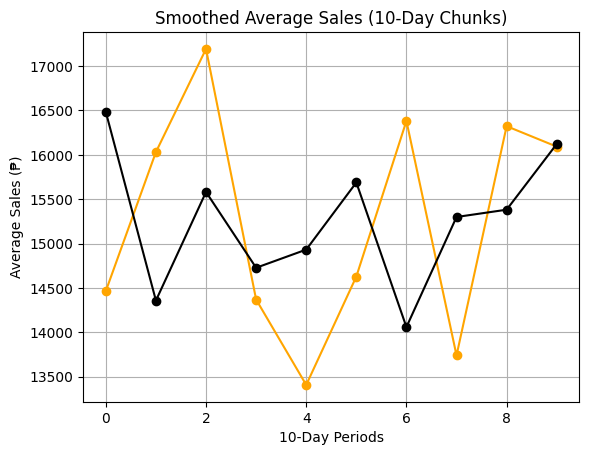

In [7]:
import numpy as np
import matplotlib.pyplot as plt

day_no = np.arange(1, 101)
daily_sales = np.random.randint(10000, 20000, 100)

avg_sales = daily_sales.reshape(-1, 10).mean(axis=1) # Average in each rows
avg_sales2 = daily_sales.reshape(-1, 10).mean(axis=0) # Average in each cols

plt.plot(avg_sales, marker='o', color='orange')
plt.plot(avg_sales2, marker='o', color='black')
plt.title("Smoothed Average Sales (10-Day Chunks)")
plt.xlabel("10-Day Periods")
plt.ylabel("Average Sales (₱)")
plt.grid(True)
plt.show()